## A-Random Forest (Same model used in original RF notebook + Explainability methods with plots)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Inspect the Dataset

In [2]:
raw_data, meta = arff.loadarff("dataset_31_credit-g.arff")
df = pd.DataFrame(raw_data)

def _decode_if_bytes(v):
    return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v

df = df.apply(lambda s: s.map(_decode_if_bytes))

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 1000 rows x 21 columns
Missing values: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [6]:
print(df.dtypes)

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object


Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


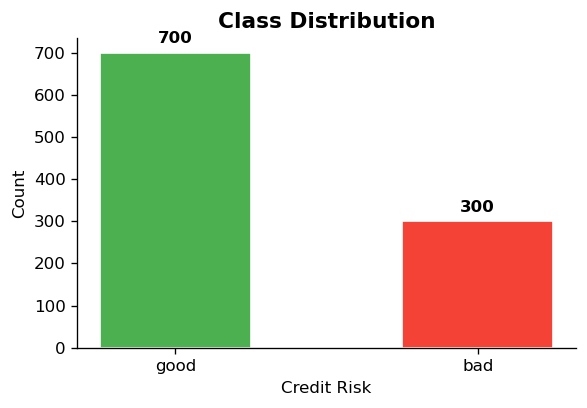

In [7]:
print("Class distribution:")
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["class"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Encode Categorical Features

In [8]:
# creating the dataset with one-hot encoding (same approach as in eda.ipynb / decision_tree.ipynb)

df_ohe_src = df.copy()

categorical_cols = df_ohe_src.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
target_col = 'class' if 'class' in df_ohe_src.columns else None

ohe_cols = [c for c in categorical_cols if c != target_col]
df_ohe = pd.get_dummies(df_ohe_src, columns=ohe_cols, drop_first=False, dtype=int)

if target_col is not None:
    X = df_ohe.drop(columns=[target_col])
    y = df_ohe[target_col]
else:
    X = df_ohe
    y = None

if y is not None and y.isna().any():
    raise ValueError("Target column 'class' contains NaN values. Re-run Cell 4 to ensure decoding succeeded.")
if X.isna().any().any():
    raise ValueError("Feature matrix contains NaNs; decoding/loading may have failed.")

if y is not None and set(['bad', 'good']).issubset(set(pd.Series(y).unique())):
    class_names = ['bad', 'good']
elif y is not None:
    class_names = sorted(pd.Series(y).unique().tolist())
else:
    class_names = None

print(f"Raw df shape: {df_ohe_src.shape}")
print(f"One-hot df_ohe shape: {df_ohe.shape}")
print(f"One-hot features shape (X): {X.shape}")
if y is not None:
    print(f"Target column: {target_col} (dtype={y.dtype})")
    print(f"Classes: {class_names}")

X.head()

Raw df shape: (1000, 21)
One-hot df_ohe shape: (1000, 62)
One-hot features shape (X): (1000, 61)
Target column: class (dtype=object)
Classes: ['bad', 'good']


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,0,1,0,...,1,0,0,1,0,0,0,1,0,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1


## 4. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
 )

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 700
Testing  samples : 300
Features         : 61


## 5. Train the Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")
print(f"  Trees         : {rf.n_estimators}")
print(f"  Features used : {rf.n_features_in_}")

Random Forest trained.
  Trees         : 50
  Features used : 61


## 6. Evaluate Performance

In [11]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=class_names, target_names=class_names))
## 7. Confusion Matrix

Accuracy : 0.7500  (75.00%)

Classification Report:
              precision    recall  f1-score   support

         bad       0.59      0.52      0.56        90
        good       0.81      0.85      0.83       210

    accuracy                           0.75       300
   macro avg       0.70      0.68      0.69       300
weighted avg       0.74      0.75      0.75       300



## 7. Confusion Matrix

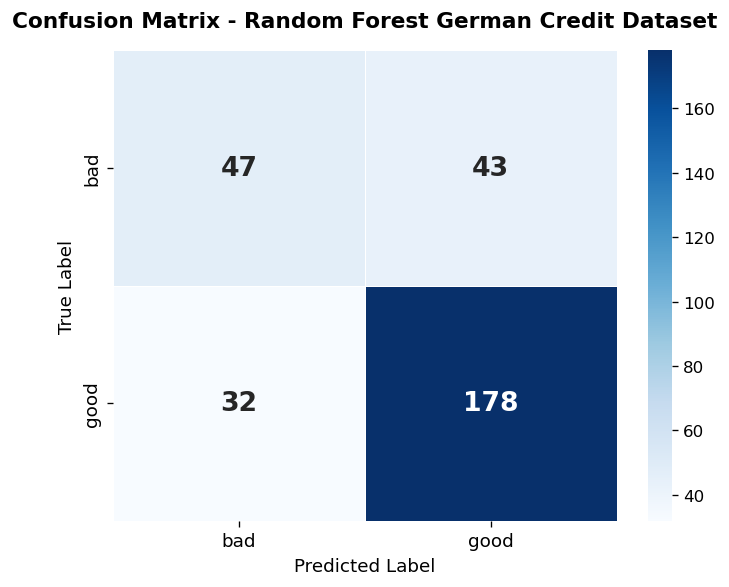

True  Negatives (bad -> bad) : 47
False Positives (bad -> good) : 43
False Negatives (good -> bad) : 32
True  Positives (good -> good) : 178


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title("Confusion Matrix - Random Forest German Credit Dataset", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"True  Negatives ({class_names[0]} -> {class_names[0]}) : {tn}")
    print(f"False Positives ({class_names[0]} -> {class_names[1]}) : {fp}")
    print(f"False Negatives ({class_names[1]} -> {class_names[0]}) : {fn}")
    print(f"True  Positives ({class_names[1]} -> {class_names[1]}) : {tp}")

## 8. Explainability (Random Forest): SHAP + Anchors


## Case Picker

In [15]:

import numpy as np

def _label_to_str(v):
    return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v)


class_names = [_label_to_str(c) for c in rf.classes_]


bad_class_name = "bad"
good_class_name = "good"

bad_class_idx = class_names.index("bad")
good_class_idx = class_names.index("good")


pred = rf.predict(X_test)
pred_labels = np.array([_label_to_str(v) for v in pred])
y_true_labels = np.array([_label_to_str(v) for v in y_test.values])


bad_idxs = np.where(pred_labels == bad_class_name)[0]
good_idxs = np.where(pred_labels == good_class_name)[0]
mis_idxs = np.where(pred_labels != y_true_labels)[0]

bad_i = int(bad_idxs[0]) if len(bad_idxs) else None
good_i = int(good_idxs[0]) if len(good_idxs) else None

mis_i = None
for idx in mis_idxs:
    idx = int(idx)
    if idx != bad_i and idx != good_i:
        mis_i = idx
        break

if mis_i is None and len(mis_idxs):
    mis_i = int(mis_idxs[0])

print("Selected indices in RF test set:")
print("  BAD predicted :", bad_i)
print("  GOOD predicted:", good_i)
print("  Misclassified :", mis_i)

print("\nClass mapping:")
print("  bad  ->", bad_class_idx)
print("  good ->", good_class_idx)


Selected indices in RF test set:
  BAD predicted : 1
  GOOD predicted: 0
  Misclassified : 8

Class mapping:
  bad  -> 0
  good -> 1


## SHAP + Plots

C:\Users\cezar\AppData\Local\Temp\ipykernel_6904\2756170889.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_bad, X_test, show=False)


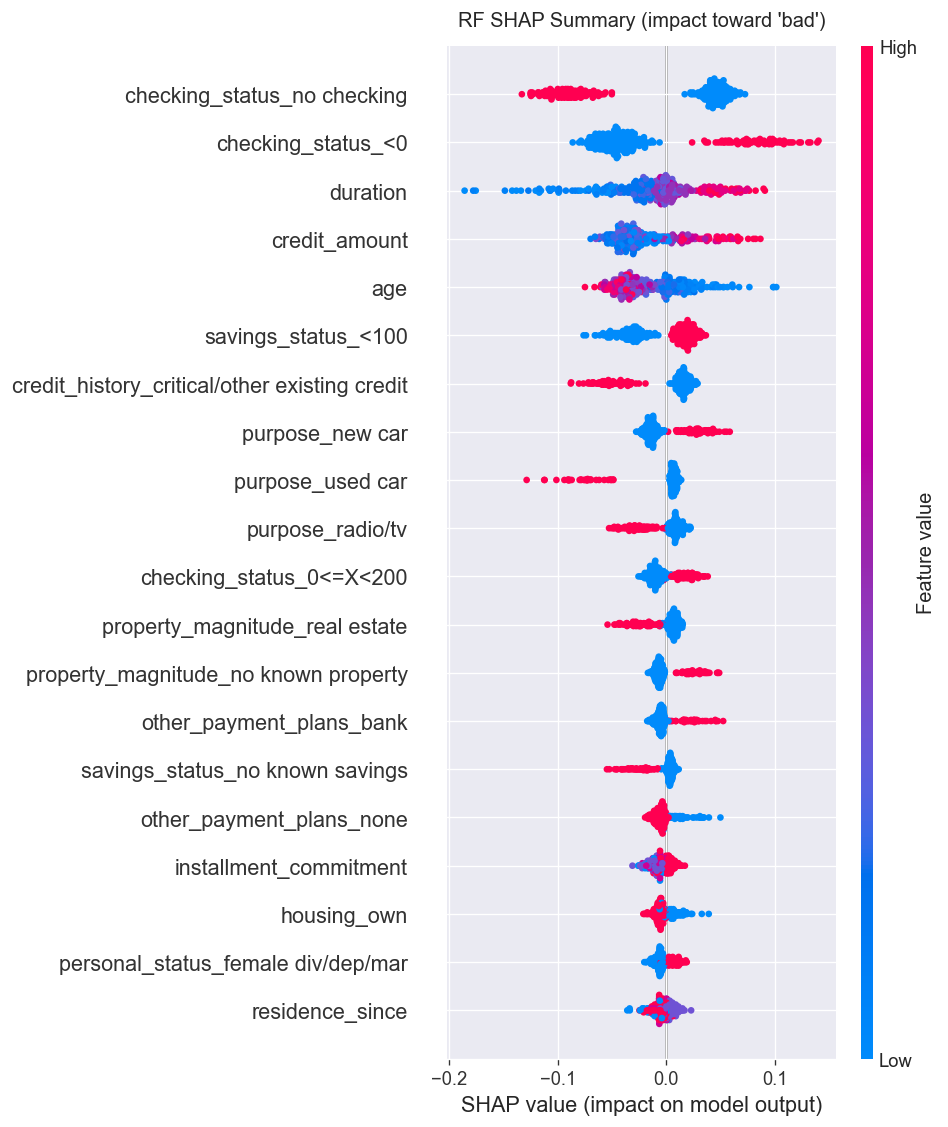

C:\Users\cezar\AppData\Local\Temp\ipykernel_6904\2756170889.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_bad, X_test, plot_type="bar", show=False)


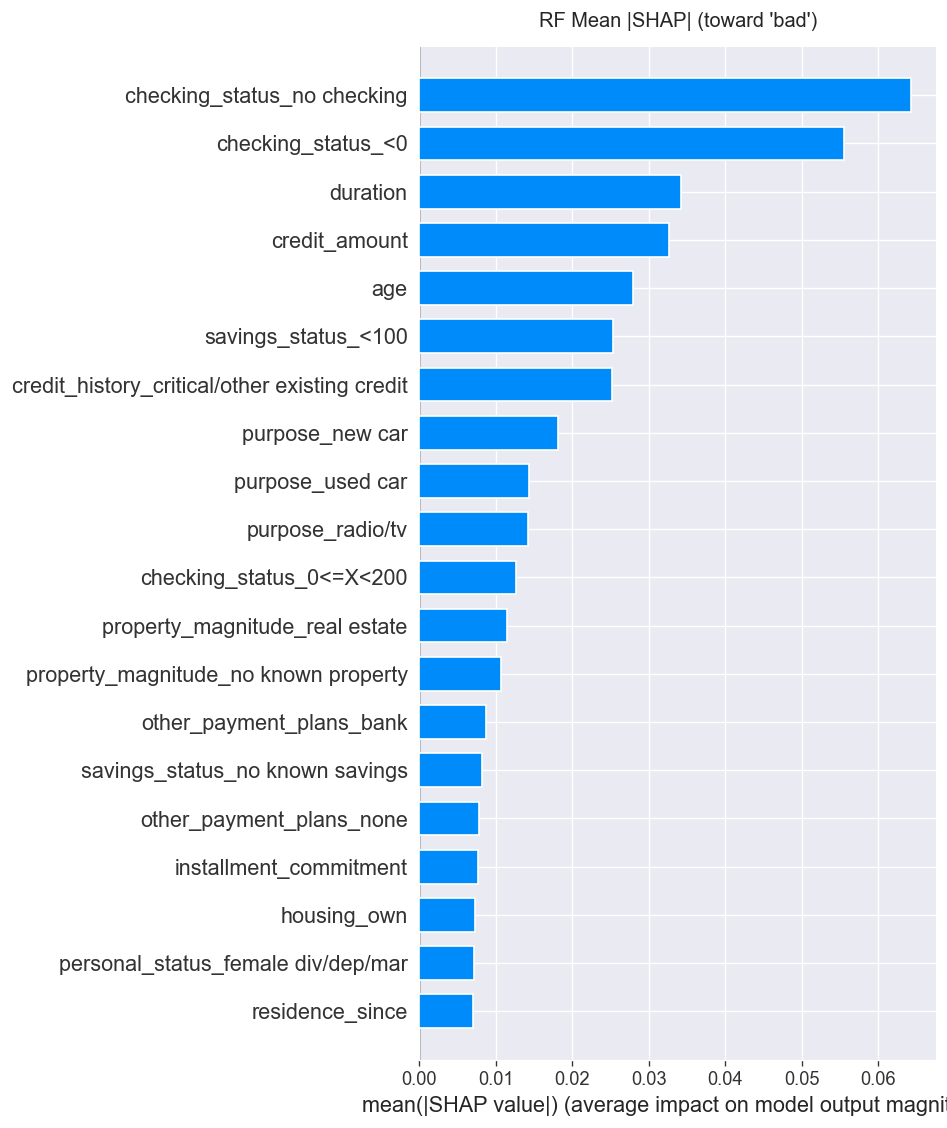

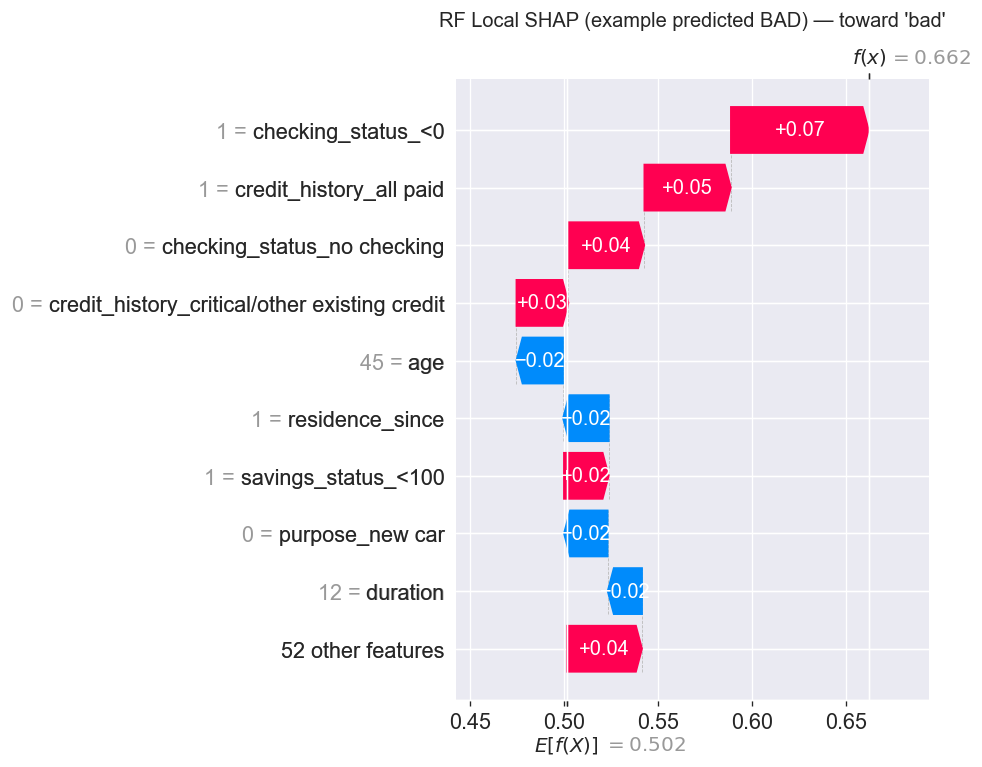

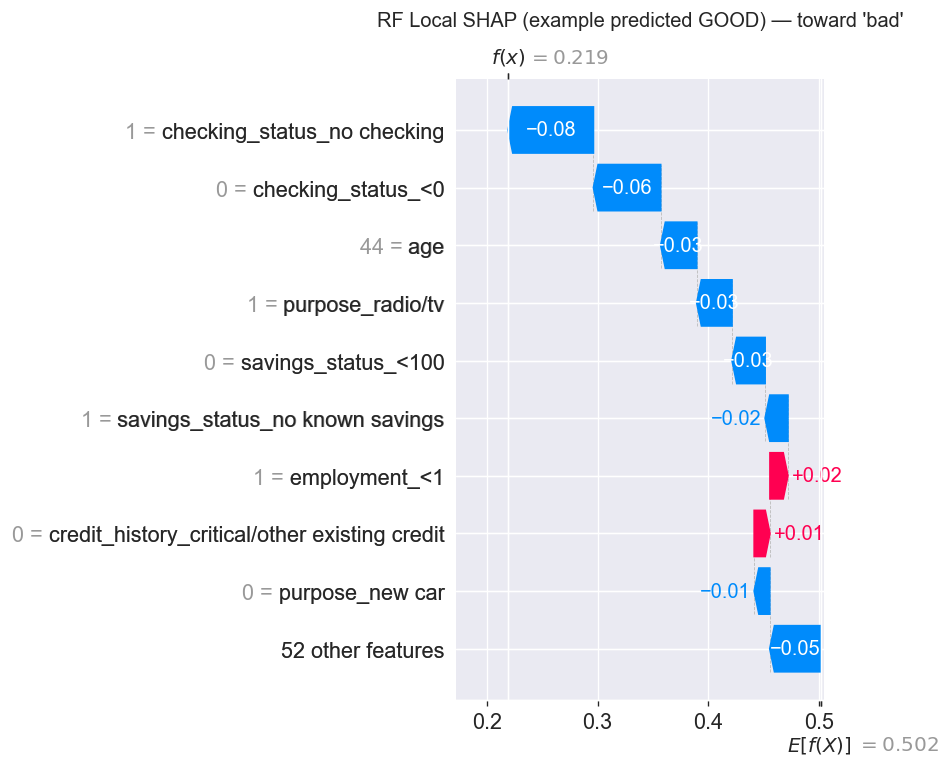

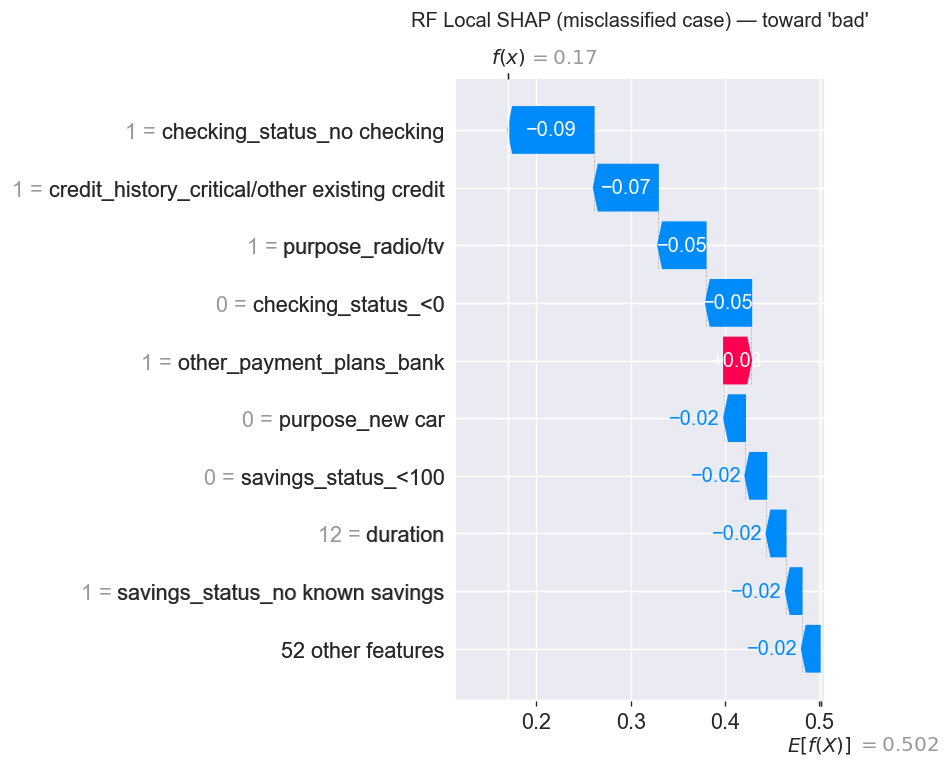

In [16]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

def get_shap_for_class(shap_values, class_index: int):
    if isinstance(shap_values, list):
        return shap_values[class_index]
    return shap_values[:, :, class_index]

# contributions toward BAD
sv_bad = get_shap_for_class(shap_values, bad_label)

# global summary
shap.summary_plot(sv_bad, X_test, show=False)
plt.title("RF SHAP Summary (impact toward 'bad')", pad=12)
plt.tight_layout()
plt.show()

# global importance
shap.summary_plot(sv_bad, X_test, plot_type="bar", show=False)
plt.title("RF Mean |SHAP| (toward 'bad')", pad=12)
plt.tight_layout()
plt.show()

#waterfall plots local
base = explainer.expected_value[bad_label] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

def shap_waterfall(idx, title):
    ex = shap.Explanation(
        values=sv_bad[idx],
        base_values=base,
        data=X_test.iloc[idx],
        feature_names=X_test.columns
    )
    shap.plots.waterfall(ex, show=False)
    plt.title(title, pad=12)
    plt.tight_layout()
    plt.show()

if bad_i is not None:
    shap_waterfall(bad_i, "RF Local SHAP (example predicted BAD) — toward 'bad'")

if good_i is not None:
    shap_waterfall(good_i, "RF Local SHAP (example predicted GOOD) — toward 'bad'")

if mis_i is not None:
    shap_waterfall(mis_i, "RF Local SHAP (misclassified case) — toward 'bad'")

## ANCHOR outputs (rules determined)

In [17]:

import numpy as np
import pandas as pd
from alibi.explainers import AnchorTabular

#feature checker
print("rf.n_features_in_:", rf.n_features_in_)
print("X_train.shape[1] :", X_train.shape[1])

if rf.n_features_in_ != X_train.shape[1]:
    raise ValueError(
        f"Mismatch between RF input features ({rf.n_features_in_}) "
        f"and X_train columns ({X_train.shape[1]})."
    )

feature_names = list(X_train.columns)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()


categorical_names = {}

def _label_to_str(v):
    return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v)


def predict_fn_proba(x):
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x_df = pd.DataFrame(x, columns=feature_names)
    return rf.predict_proba(x_df)

#explainer fiter
anchor_explainer = AnchorTabular(
    predictor=predict_fn_proba,
    feature_names=feature_names,
    categorical_names=categorical_names,
    seed=RANDOM_STATE
)
anchor_explainer.fit(X_train_np)

class_names = [_label_to_str(c) for c in rf.classes_]

if "bad" not in class_names or "good" not in class_names:
    raise ValueError(f"Expected RF classes ['bad', 'good'], got: {class_names}")

bad_class_name = "bad"
good_class_name = "good"


bad_class_idx = class_names.index("bad")
good_class_idx = class_names.index("good")


pred = rf.predict(X_test)
pred_labels = np.array([_label_to_str(v) for v in pred])
y_true_labels = np.array([_label_to_str(v) for v in y_test.values])

bad_candidates = np.where(pred_labels == bad_class_name)[0]
good_candidates = np.where(pred_labels == good_class_name)[0]
mis_candidates = np.where(pred_labels != y_true_labels)[0]

bad_i = int(bad_candidates[0]) if len(bad_candidates) else None
good_i = int(good_candidates[0]) if len(good_candidates) else None

mis_i = None
for idx in mis_candidates:
    idx = int(idx)
    if idx != bad_i and idx != good_i:
        mis_i = idx
        break

if mis_i is None and len(mis_candidates):
    mis_i = int(mis_candidates[0])

print("Selected indices in RF test set:", {
    "bad": bad_i,
    "good": good_i,
    "mis": mis_i
})

#thersholds
def print_anchor(idx, thresholds=(0.95, 0.90, 0.85, 0.80), beam_size=100):
    x = X_test_np[idx]

    pred_label_str = _label_to_str(rf.predict(X_test.iloc[[idx]])[0])

    best_exp = None
    best_prec = -1.0
    best_t = None

    for t in thresholds:
        exp = anchor_explainer.explain(
            x,
            threshold=t,
            beam_size=beam_size,
            stop_on_first=False,
            max_anchor_size=6,
            coverage_samples=2000,
            batch_size=200
        )

        anchor_list = exp.data.get("anchor", [])
        prec_data = exp.data.get("precision")
        prec = float(np.array(prec_data).ravel()[0]) if prec_data is not None else -1.0

        # track best result even if threshold is not met
        if prec > best_prec:
            best_exp, best_prec, best_t = exp, prec, t

        # accept only non-empty anchors meeting threshold
        if anchor_list and prec >= t:
            print("\n" + "=" * 80)
            print("Index:", idx, "| RF prediction:", pred_label_str)
            print("Target precision threshold:", t)
            print("Anchor rule:")
            print("  " + " AND ".join(anchor_list))
            print("Precision:", prec)
            print("Coverage :", exp.data.get("coverage"))
            return exp

    # fallback: no threshold met
    anchor_list = best_exp.data.get("anchor", []) if best_exp is not None else []
    print("\n" + "=" * 80)
    print("Index:", idx, "| RF prediction:", pred_label_str)
    print("No rule met the requested thresholds; showing best found rule instead.")
    print("Best attempted threshold:", best_t)
    print("Anchor rule:")
    print("  " + (" AND ".join(anchor_list) if anchor_list else "(EMPTY)"))
    print("Precision:", best_prec)
    print("Coverage :", best_exp.data.get("coverage") if best_exp is not None else None)
    return best_exp

#explanations
if bad_i is not None:
    print_anchor(bad_i)

if good_i is not None:
    print_anchor(good_i)

if mis_i is not None:
    print_anchor(mis_i)

rf.n_features_in_: 61
X_train.shape[1] : 61
Selected indices in RF test set: {'bad': 1, 'good': 0, 'mis': 8}

Index: 1 | RF prediction: bad
Target precision threshold: 0.95
Anchor rule:
  savings_status_no known savings <= 0.00 AND savings_status_<100 > 0.00 AND checking_status_<0 > 0.00 AND property_magnitude_car > 0.00 AND credit_amount <= 1336.00 AND savings_status_500<=X<1000 <= 0.00
Precision: 1.0
Coverage : 0.25

Index: 0 | RF prediction: good
Target precision threshold: 0.95
Anchor rule:
  checking_status_no checking > 0.00 AND checking_status_<0 <= 1.00 AND age > 33.00
Precision: 0.9682274247491639
Coverage : 0.3914285714285714

Index: 8 | RF prediction: good
Target precision threshold: 0.95
Anchor rule:
  checking_status_no checking > 0.00 AND checking_status_<0 <= 0.00 AND duration <= 12.00
Precision: 0.9546875
Coverage : 0.3914285714285714
